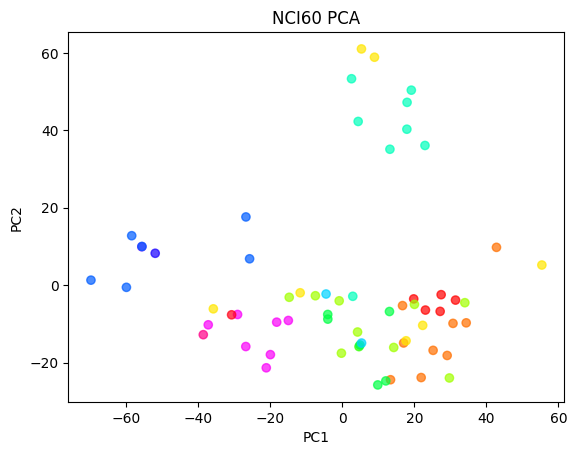

Component    | Individual Variance  | Cumulative Variance 
-----------------------------------------------------------
PC1          | 11.36%               | 11.36%              
PC2          | 6.76%                | 18.12%              
PC3          | 5.75%                | 23.87%              
PC4          | 4.25%                | 28.11%              
PC5          | 3.73%                | 31.85%              
PC6          | 3.62%                | 35.47%              
PC7          | 3.07%                | 38.53%              
PC8          | 2.69%                | 41.22%              
PC9          | 2.53%                | 43.75%              
PC10         | 2.38%                | 46.13%              


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA

X_raw = pd.read_csv('data/nci60_data.csv', index_col=0)
labs = pd.read_csv('data/nci60_labs.csv', index_col=0)
X = scale(X_raw)
pca = PCA()
scores = pca.fit_transform(X)
color_id = pd.factorize(labs.iloc[:, 0])[0]
plt.scatter(scores[:, 0], scores[:, 1], c=color_id, cmap='hsv', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('NCI60 PCA')
plt.show()
print(f"{'Component':<12} | {'Individual Variance':<20} | {'Cumulative Variance':<20}")
print("-" * 59)
for i, (var, cum_var) in enumerate(zip(pca.explained_variance_ratio_[:10], np.cumsum(pca.explained_variance_ratio_)[:10]), 1):
    print(f"PC{i:<10} | {var:<20.2%} | {cum_var:<20.2%}")

Ridge MSE: 0.08555291732808021
Ridge R2: 0.05965631801655291
MLP MSE: 0.006760717987940044
MLP R2: 0.9256904539999288


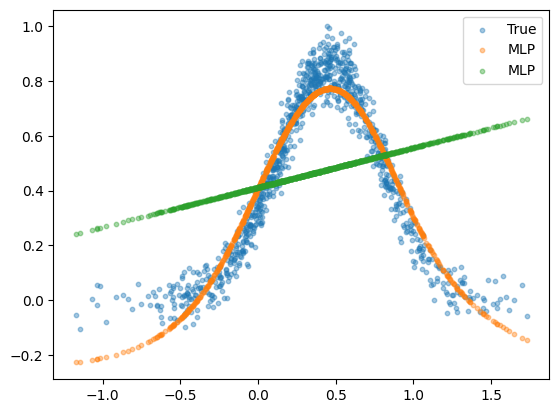

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
np.random.seed(0)
N = 2000
X = 0.5 * np.random.normal(size=N) + 0.35
Xt = 0.75 * X - 0.35
X = X.reshape((N, 1))
y = -(8 * Xt**2 + 0.1 * Xt + 0.1) + 0.05 * np.random.normal(size=N)
y = np.exp(y) + 0.05 * np.random.normal(size=N)
y = y / max(abs(y))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
ridge = Ridge().fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

mlp = MLPRegressor(hidden_layer_sizes=(16, 8), activation='tanh',
                   max_iter=1000, random_state=0)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)
print('Ridge MSE:', mean_squared_error(y_test, ridge_pred))
print('Ridge R2:', r2_score(y_test, ridge_pred))
print('MLP MSE:', mean_squared_error(y_test, mlp_pred))
print('MLP R2:', r2_score(y_test, mlp_pred))
plt.scatter(X_test[:, 0], y_test, s=10, alpha=0.4, label='True')
plt.scatter(X_test[:, 0], mlp_pred, s=10, alpha=0.4, label='MLP')
plt.scatter(X_test[:, 0], ridge_pred, s=10, alpha=0.4, label='MLP')
plt.legend()
plt.show()

               PC1       PC2       PC3       PC4
Murder    0.535899 -0.418181 -0.341233 -0.649228
Assault   0.583184 -0.187986 -0.268148  0.743407
UrbanPop  0.278191  0.872806 -0.378016 -0.133878
Rape      0.543432  0.167319  0.817778 -0.089024
PVE: [0.62006039 0.24744129 0.0891408  0.04335752]
Cumulative PVE: [0.62006039 0.86750168 0.95664248 1.        ]


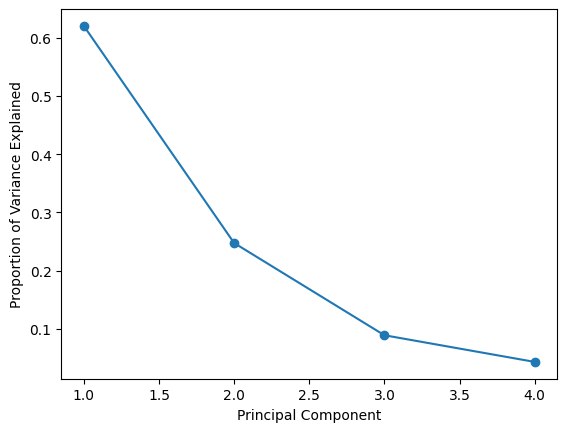

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
df = pd.read_csv('data/USArrests.csv', index_col=0)
X = pd.DataFrame(scale(df), index=df.index, columns=df.columns)
pca = PCA()
scores = pca.fit_transform(X)
loadings = pd.DataFrame(
    pca.components_.T,
    index=df.columns,
    columns=[f'PC{i}' for i in range(1, X.shape[1] + 1)]
)
print(loadings)
print('PVE:', pca.explained_variance_ratio_)
print('Cumulative PVE:', np.cumsum(pca.explained_variance_ratio_))
plt.plot(range(1, 5), pca.explained_variance_ratio_, '-o')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.show()

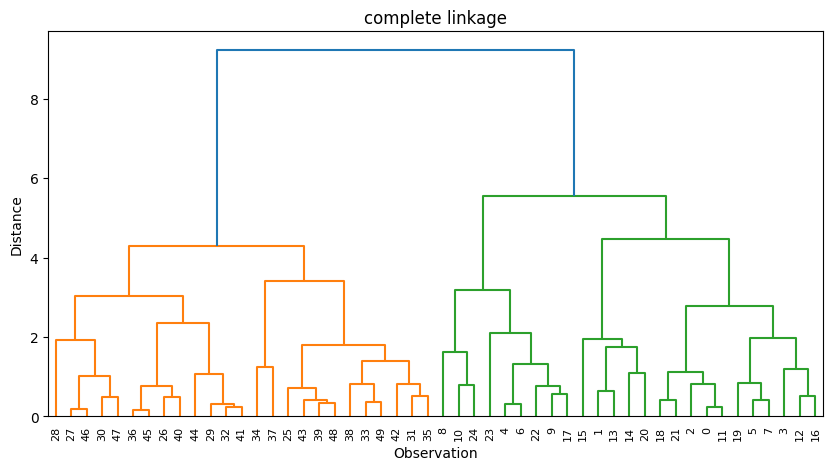

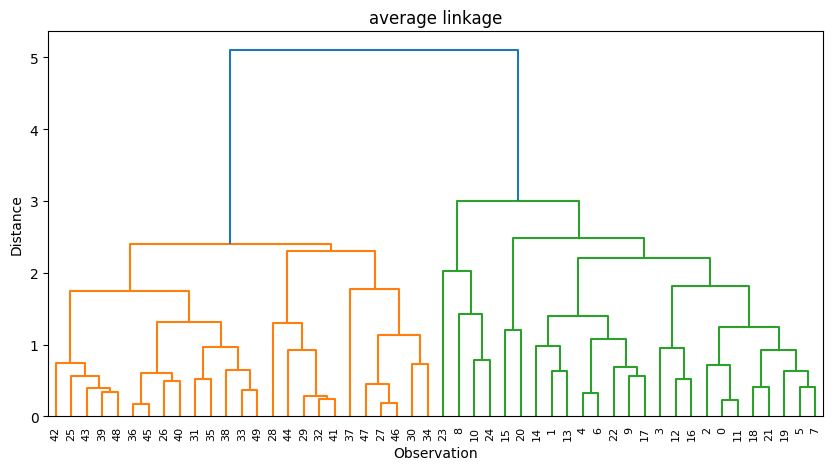

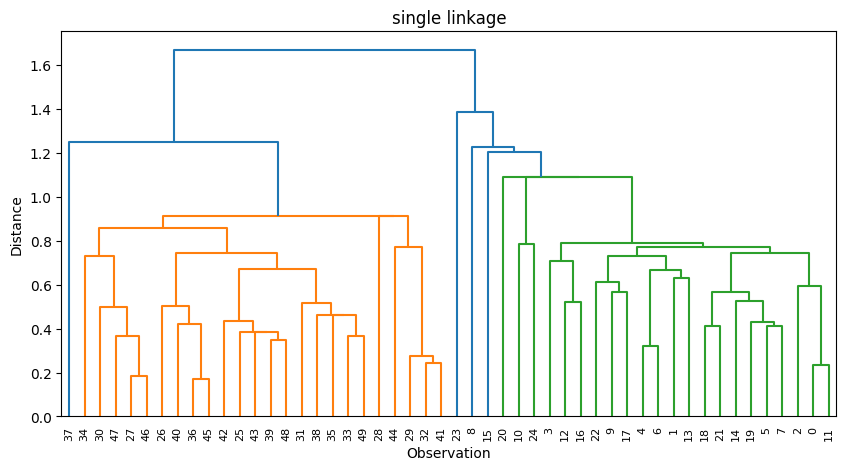

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
np.random.seed(123)
X = np.random.randn(50, 2)
X[:25, 0] = X[:25, 0] + 3
X[:25, 1] = X[:25, 1] - 4
for method in ['complete', 'average', 'single']:
    hc = linkage(X, method=method)
    plt.figure(figsize=(10, 5))
    dendrogram(hc, leaf_rotation=90, leaf_font_size=8)
    plt.title(f'{method} linkage')
    plt.xlabel('Observation')
    plt.ylabel('Distance')
    plt.show()
hc_complete = linkage(X, method='complete')
clusters = cut_tree(hc_complete, n_clusters=2).reshape(-1)
print(clusters)

In [23]:
specific_observations = [0, 24, 25, 49]
for idx in specific_observations:print(f"Observation {idx} -> Cluster {clusters[idx]}")

Observation 0 -> Cluster 0
Observation 24 -> Cluster 0
Observation 25 -> Cluster 1
Observation 49 -> Cluster 1


In [17]:
print("Observations in Cluster 0:", np.where(clusters == 0)[0])
print("Observations in Cluster 1:", np.where(clusters == 1)[0])

Observations in Cluster 0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Observations in Cluster 1: [25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49]


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
df = pd.read_csv('data/boston.csv')
X = df.drop('medv', axis=1)
y = df['medv']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1)
for lr in [0.01, 0.2]:
    model = GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=lr,
        max_depth=4,
        random_state=1    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f'Learning rate {lr}, test MSE:', mean_squared_error(y_test, pred))

Learning rate 0.01, test MSE: 8.496720031212883
Learning rate 0.2, test MSE: 7.531670321833465


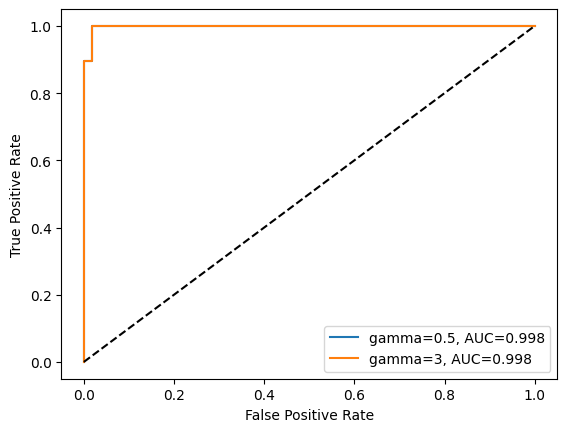

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
np.random.seed(1)
X = np.random.randn(200, 2)
X[:100] = X[:100] + 2
X[100:150] = X[100:150] - 2
y = np.repeat([1, 0], 100)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=1)
for gamma in [0.5, 3]:
    model = SVC(kernel='rbf', gamma=gamma, C=1)
    model.fit(X_train, y_train)
    scores = model.decision_function(X_test)
    fpr, tpr, threshold = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'gamma={gamma}, AUC={roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

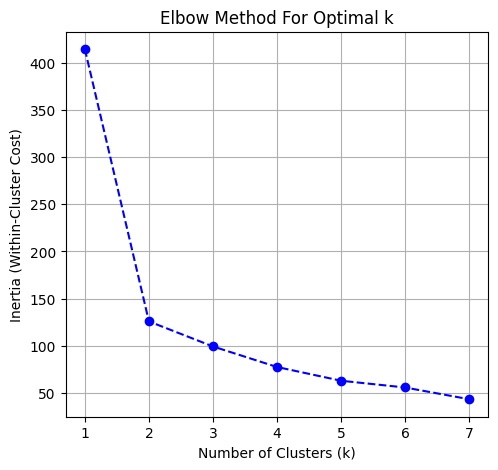

In [ ]:
inertias = []
K_range = range(1, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X)
    inertias.append(km.inertia_)  # Total within-cluster sum of squares

# Plot the Elbow Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Cost)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)

K=2
Inertia: 125.86305660307788
Centers:
 [[ 0.20742071 -0.1255273 ]
 [ 3.03552977 -4.00898689]]


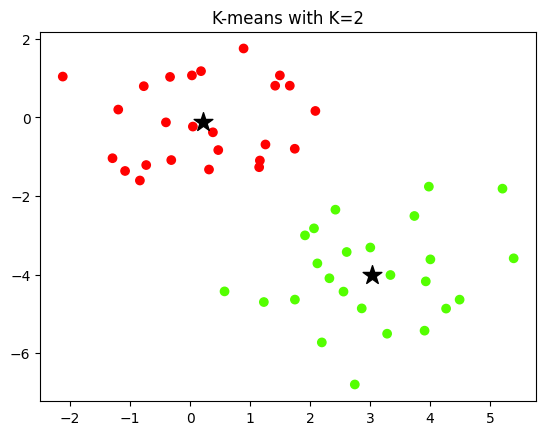

K=3
Inertia: 99.2951930365756
Centers:
 [[ 0.20742071 -0.1255273 ]
 [ 3.72610332 -3.29900419]
 [ 2.28740842 -4.77813481]]


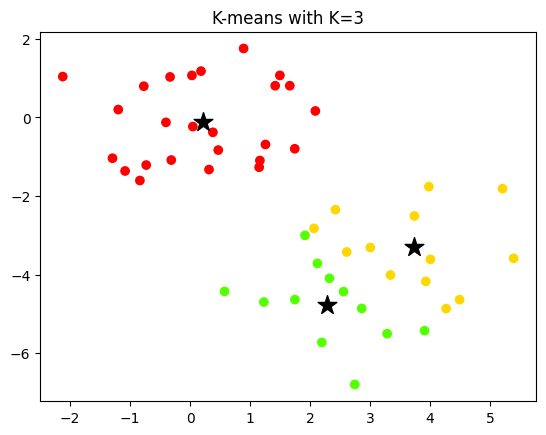

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
np.random.seed(123)
X = np.random.randn(50, 2)
X[:25, 0] = X[:25, 0] + 3
X[:25, 1] = X[:25, 1] - 4
for k in [2, 3]:
    km = KMeans(n_clusters=k, n_init=20, random_state=123)
    km.fit(X)
    print(f'K={k}')
    print('Inertia:', km.inertia_)
    print('Centers:\n', km.cluster_centers_)
    plt.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='prism')
    plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                marker='*', s=200, color='black')
    plt.title(f'K-means with K={k}')
    plt.show()

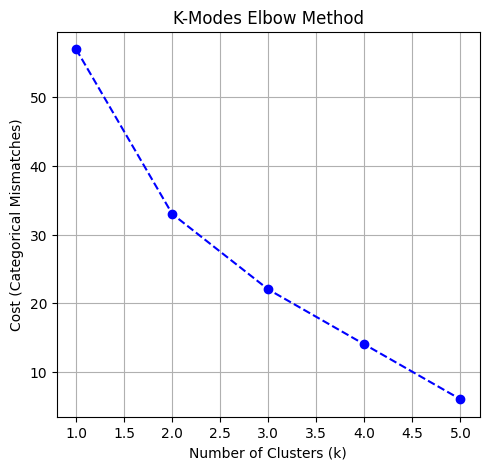

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from kmodes.kmodes import KModes

# Generation of synthetic categorical data (50 samples, 2 categories each)
np.random.seed(123)
cat1 = np.random.choice(['A', 'B', 'C'], size=50)
cat2 = np.random.choice(['X', 'Y'], size=50)
df_cat = pd.DataFrame({'Cat1': cat1, 'Cat2': cat2})

costs = []  # ELBOW PLOT
K_range = range(1, 6)
for k in K_range:
    km = KModes(n_clusters=k, init='Cao', n_init=5, random_state=42)
    km.fit(df_cat)
    costs.append(km.cost_)  # Total sum of categorical mismatches

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, costs, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Cost (Categorical Mismatches)')
plt.title('K-Modes Elbow Method')
plt.grid(True)


K=2
Cost: 33.0
Centroids (Modes):
 [['A' 'X']
 ['C' 'Y']]


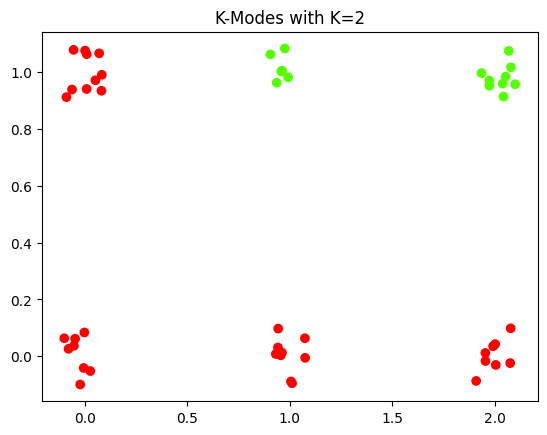

K=3
Cost: 22.0
Centroids (Modes):
 [['B' 'X']
 ['C' 'Y']
 ['A' 'Y']]


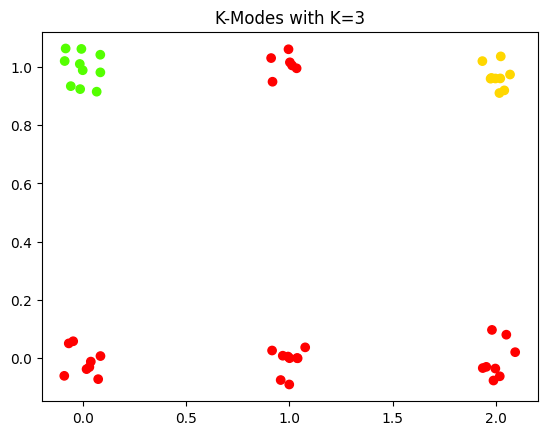

In [28]:

for k in [2, 3]:
    km = KModes(n_clusters=k, init='Cao', n_init=5, random_state=123)
    labels = km.fit_predict(df_cat)
    print(f'K={k}')
    print('Cost:', km.cost_)
    print('Centroids (Modes):\n', km.cluster_centroids_)
    # Jittering points slightly just to make categorical overlaps visible in scatter
    plt.scatter(df_cat.iloc[:, 0].astype('category').cat.codes + np.random.uniform(-0.1, 0.1, 50),
                df_cat.iloc[:, 1].astype('category').cat.codes + np.random.uniform(-0.1, 0.1, 50), 
                c=labels, cmap='prism')
    plt.title(f'K-Modes with K={k}')
    plt.show()

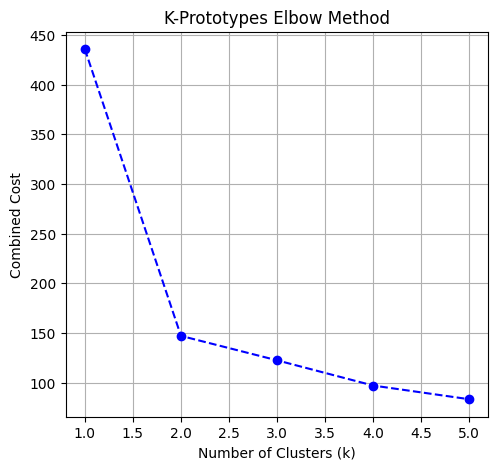

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from kmodes.kprototypes import KPrototypes

# Generation of mixed data (50 samples: 2 numerical columns, 1 categorical column)
np.random.seed(123)
num_data = np.random.randn(50, 2)
num_data[:25, 0] += 3
num_data[:25, 1] -= 4
cat_data = np.random.choice(['High', 'Low'], size=50).reshape(-1, 1)
df_mixed = pd.DataFrame(np.hstack([num_data, cat_data]), columns=['Num1', 'Num2', 'Cat1'])
df_mixed[['Num1', 'Num2']] = df_mixed[['Num1', 'Num2']].apply(pd.to_numeric)

cat_indices = [2]  # Index of the categorical column
costs = []  # ELBOW PLOT
K_range = range(1, 6)
for k in K_range:
    kp = KPrototypes(n_clusters=k, init='Cao', n_init=5, random_state=42)
    kp.fit(df_mixed, categorical=cat_indices)
    costs.append(kp.cost_)  # Combined Euclidean + Category mismatch cost

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, costs, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Combined Cost')
plt.title('K-Prototypes Elbow Method')
plt.grid(True)


In [33]:
df_mixed.head()

,Num1,Num2,Cat1
0,1.914369,-3.002655,Low
1,3.282978,-5.506295,Low
2,2.421400,-2.348563,Low
3,0.573321,-4.428913,High
4,4.265936,-4.866740,High


K=2
Cost: 147.11851942811052
Centroids (Means & Modes):
 [['0.20742070720557912' '-0.12552729541171007' 'Low']
 ['3.0355297683828955' '-4.008986886215325' 'Low']]


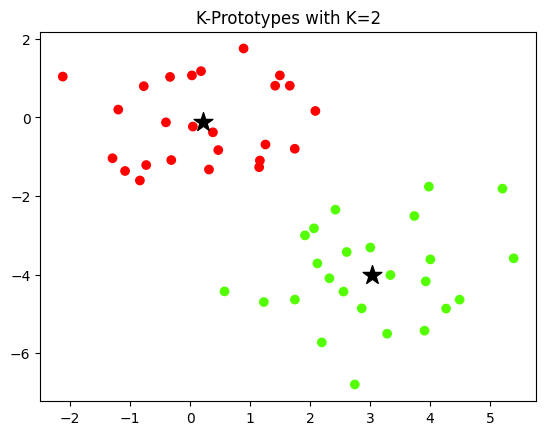

K=3
Cost: 122.52498845976723
Centroids (Means & Modes):
 [['0.7752734306781636' '0.505939971000685' 'High']
 ['3.0355297683828955' '-4.008986886215325' 'Low']
 ['-0.4077530765563875' '-0.809616834025138' 'Low']]


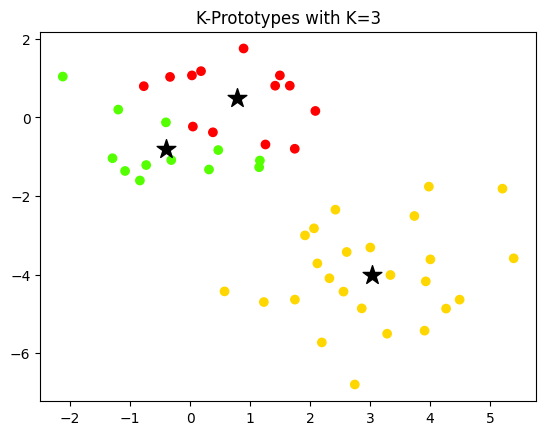

In [35]:

for k in [2, 3]:
    kp = KPrototypes(n_clusters=k, init='Cao', n_init=5, random_state=123)
    labels = kp.fit_predict(df_mixed, categorical=cat_indices)
    print(f'K={k}')
    print('Cost:', kp.cost_)
    print('Centroids (Means & Modes):\n', kp.cluster_centroids_)
    # Plotting using the 2 numerical dimensions
    plt.scatter(df_mixed.iloc[:, 0], df_mixed.iloc[:, 1], c=labels, cmap='prism')
    plt.scatter(kp.cluster_centroids_[:, 0].astype(float), kp.cluster_centroids_[:, 1].astype(float),
                marker='*', s=200, color='black')
    plt.title(f'K-Prototypes with K={k}')
    plt.show()